In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_exploration.path_variables import PATH
PATH


'/Users/karolina/data_vis/superstore_dataset/Superstore.csv'

In [15]:
df = pd.read_csv(PATH, encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
df.info()
df.describe().T
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

1.Hypothese : Schnellere Versandarten (z.B. "First Class") haben im Durchschnitt deutlich kürzere Lieferzeiten als "Standard Class".

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Ship_Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date', 'Ship Date', 'Ship Mode', 'Ship_Duration']].head()


,Order Date,Ship Date,Ship Mode,Ship_Duration
0,2016-11-08,2016-11-11,Second Class,3
1,2016-11-08,2016-11-11,Second Class,3
2,2016-06-12,2016-06-16,Second Class,4
3,2015-10-11,2015-10-18,Standard Class,7
4,2015-10-11,2015-10-18,Standard Class,7


In [29]:
ship_mode = df.groupby('Ship Mode')['Ship_Duration'].agg(['mean', 'min', 'max', 'count']).round(1)
ship_mode


,mean,min,max,count
Ship Mode,,,,
First Class,2.2,1,4,1538
Same Day,0.0,0,1,543
Second Class,3.2,1,5,1945
Standard Class,5.0,3,7,5968


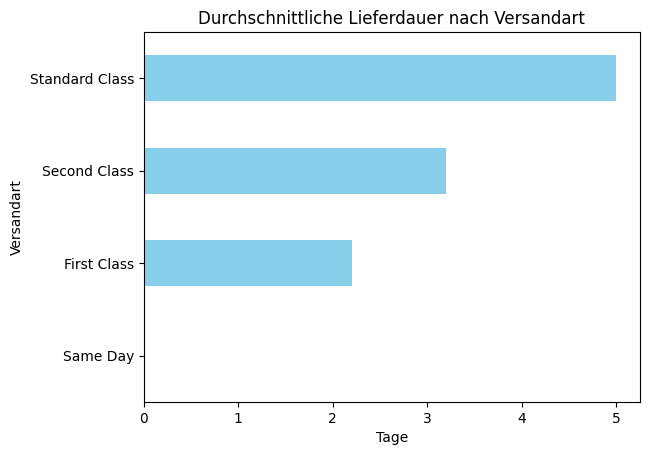

In [51]:
ship_mode['mean'].sort_values().plot(kind='barh', color='skyblue', title='Durchschnittliche Lieferdauer nach Versandart')
plt.xlabel('Tage')
plt.ylabel('Versandart')
plt.show()


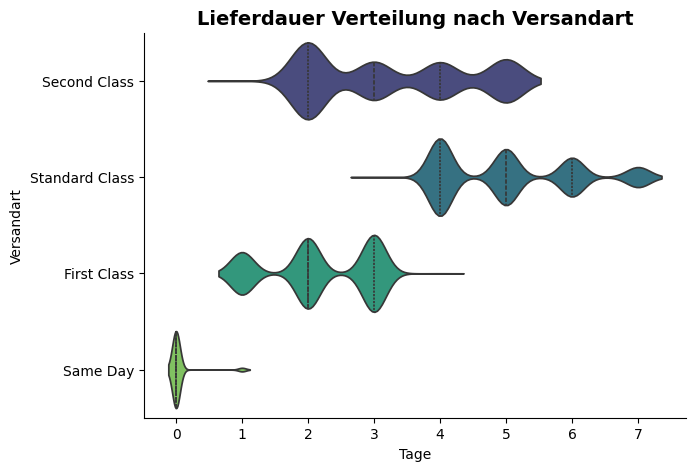

In [47]:
plt.figure(figsize=(7, 5))
sns.violinplot(
    x='Ship_Duration',
    y='Ship Mode',
    data=df,
    hue='Ship Mode',       
    legend=False,         
    inner='quartile',
    palette='viridis'
)
plt.title("Lieferdauer Verteilung nach Versandart", fontsize=14, weight='bold')
plt.xlabel("Tage")
plt.ylabel("Versandart")
sns.despine()
plt.show()

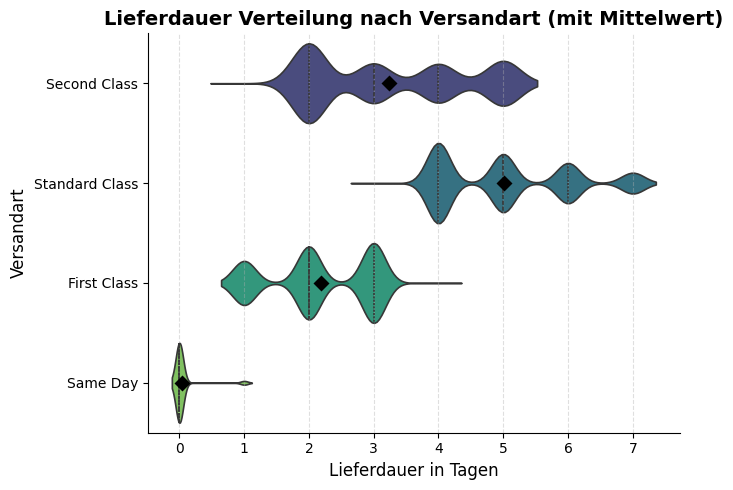

In [49]:
plt.figure(figsize=(7, 5))


sns.violinplot(
    x='Ship_Duration',
    y='Ship Mode',
    data=df,
    hue='Ship Mode',
    legend=False,
    inner='quartile',
    palette='viridis',
    linewidth=1.2
)

sns.pointplot(
    x='Ship_Duration',
    y='Ship Mode',
    data=df,
    estimator='mean',
    color='black',
    markers='D',
    linestyle='none',          
    err_kws={'linewidth': 0},  
    markersize=6              
)

plt.title("Lieferdauer Verteilung nach Versandart (mit Mittelwert)", fontsize=14, weight='bold')
plt.xlabel("Lieferdauer in Tagen", fontsize=12)
plt.ylabel("Versandart", fontsize=12)
sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()